In [128]:
# -*- coding: utf-8 -*-
"""


Actualizado: 16 de septiembre de 2025
"""
# ---------- Librerias -------------
import csv
import os
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import statistics as stats
import math
import re
from datetime import datetime

import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx
from pyproj import Transformer
import numpy as np
# ---------- Funciones -------------

def safe_div(a, b):
    return abs((a - b) / b) if b != 0 else abs(a - b)

def Clasification_Results(Ruta_Archivo: str) -> dict:
    Nombre_Dispositivo = Ruta_Archivo.split("Results_")[-1].split("_")[0]
    Model={Nombre_Dispositivo: {}}

    with open(Ruta_Archivo, mode="r", newline='', encoding='utf-8') as infile:
        reader = csv.DictReader(infile)
        header = reader.fieldnames

        for header_index in range(len(header)):
            model_name = header[header_index].split(' - ')[0]
            Data_type = header[header_index].split(' - ')[-1]
            
            if(Data_type == 'prediction'):
                Model[Nombre_Dispositivo][model_name] = { 
                    'Embarcacion': 0,
                    'Falso_Negativo':0,
                    'Falso_Positivo':0,
                    'No_Embarcacion':0,
                    'Probs':[],
                    'Speed':[]
                    }
        for row in reader:
            for field, column in row.items():
                model_name = field.split(' - ')[0]
                Data_type = field.split(' - ')[-1]
                
                if(Data_type == 'prediction'):
                    if(row['Main_Label']==column):
                        if(column=='1'):
                            Model[Nombre_Dispositivo][model_name]['Embarcacion']+=1
                        else:
                            Model[Nombre_Dispositivo][model_name]['No_Embarcacion']+=1
                    else:
                        if(column=='1'):
                            Model[Nombre_Dispositivo][model_name]['Falso_Positivo']+=1
                        else:
                            Model[Nombre_Dispositivo][model_name]['Falso_Negativo']+=1
                
                elif(Data_type == 'conf'):
                    Model[Nombre_Dispositivo][model_name]['Probs'].append(float(column))

                elif(Data_type == 'time [ms]'):
                    Model[Nombre_Dispositivo][model_name]['Speed'].append(float(column))

    return Model

def Segmentation_Results(Ruta_Archivo: str) -> dict:
    Nombre_Dispositivo = Ruta_Archivo.split("Results_")[-1].split("_")[0]
    Model={Nombre_Dispositivo: {}}

    with open(Ruta_Archivo, mode="r", newline='', encoding='utf-8') as infile:
        reader = csv.DictReader(infile)
        header = reader.fieldnames

        for header_index in range(len(header)):
            model_name = header[header_index].split(' - ')[0]
            Data_type = header[header_index].split(' - ')[-1]
            
            if(Data_type == 'prediction'):
                Model[Nombre_Dispositivo][model_name] = { 
                    'Embarcacion': 0,
                    'Falso_Negativo':0,
                    'Falso_Positivo':0,
                    'No_Embarcacion':0,
                    'Probs':[],
                    'Speed':[]
                    }
        for idx, row in enumerate(reader, start=0):
            for field, column in row.items():
                model_name = field.split(' - ')[0]
                Data_type = field.split(' - ')[-1]
                
                if(Data_type == 'prediction'):
                    if(row['Main_Label']==column):
                        if(column=='0'):
                            Model[Nombre_Dispositivo][model_name]['No_Embarcacion']+=1
                        else:
                            DB_Segments = row['Segments']
                            DB_Segments = DB_Segments.strip("[]").split(",")
                            DB_Segments = [item.strip().strip("'").strip('"').strip().split() for item in DB_Segments]   
                            DB_Segments =  [list(map(float,item[1:])) for item in DB_Segments]        

                            YOLO_Segments = row[f"{model_name} - segment"]
                            YOLO_Segments = YOLO_Segments.strip("[]").split(",")
                            YOLO_Segments = [item.strip().strip("'").strip('"').strip().split() for item in YOLO_Segments]   
                            YOLO_Segments =  [list(map(float,item[1:])) for item in YOLO_Segments]        

                            for DB_Segment in DB_Segments:
                                for YOLO_Segment in YOLO_Segments:

                                    if (safe_div(DB_Segment[0],YOLO_Segment[0])<5/100 and 
                                        safe_div(DB_Segment[1],YOLO_Segment[1])<5/100 and
                                        safe_div(DB_Segment[2],YOLO_Segment[2])<5/100 and
                                        safe_div(DB_Segment[3],YOLO_Segment[3])<5/100):
                                        
                                        Model[Nombre_Dispositivo][model_name]['Embarcacion']+=1
                                    else:
                                        Model[Nombre_Dispositivo][model_name]['Falso_Positivo']+=1

                    else:
                        if(column=='1'):
                            Model[Nombre_Dispositivo][model_name]['Falso_Positivo']+=1
                        else:
                            Model[Nombre_Dispositivo][model_name]['Falso_Negativo']+=1

                elif(Data_type == 'conf'):
                    Conf_List = column
                    Conf_List = [float(x) for x in Conf_List.strip("[]").split(",")]
                    for conf in Conf_List:
                        Model[Nombre_Dispositivo][model_name]['Probs'].append(conf)

                elif(Data_type == 'time [ms]'):
                    Model[Nombre_Dispositivo][model_name]['Speed'].append(float(column))

    return Model

def modelo_sort_key(modelo: str, type_order, size_order):
    _, size, tipo = modelo.split("_")
    return (type_order.index(tipo), size_order.index(int(size)))

def extract_number(value):
    match = re.search(r"[-+]?\d*\.?\d+", value)
    return float(match.group()) if match else None


Matriz de confusion media - (promediado con los experimentos en diversos dispositivos)
Para el modelo Modelo_1056_ExtraLarge:
Embarcaciones: 11.433151651170247±0.0%
Sin embarcaciones: 87.476755370311±0.0%
Falso Negativo: 0.6027572940044886±0.0%
Falso Positivo: 0.4873356845142674±0.0%

Para el modelo Modelo_832_ExtraLarge:
Embarcaciones: 11.394677781340173±0.0%
Sin embarcaciones: 87.62423853799295±0.0%
Falso Negativo: 0.6412311638345624±0.0%
Falso Positivo: 0.33985251683231804±0.0%

Para el modelo Modelo_640_ExtraLarge:
Embarcaciones: 11.760179544725874±0.0%
Sin embarcaciones: 87.68194934273805±0.0%
Falso Negativo: 0.2757294004488618±0.0%
Falso Positivo: 0.28214171208720745±0.0%

Para el modelo Modelo_416_ExtraLarge:
Embarcaciones: 11.856364219301058±0.0%
Sin embarcaciones: 87.84866944533505±0.0%
Falso Negativo: 0.17954472587367745±0.0%
Falso Positivo: 0.11542160949022122±0.0%

Para el modelo Modelo_1056_Large:
Embarcaciones: 11.51651170246874±0.0%
Sin embarcaciones: 87.62423853799295±0

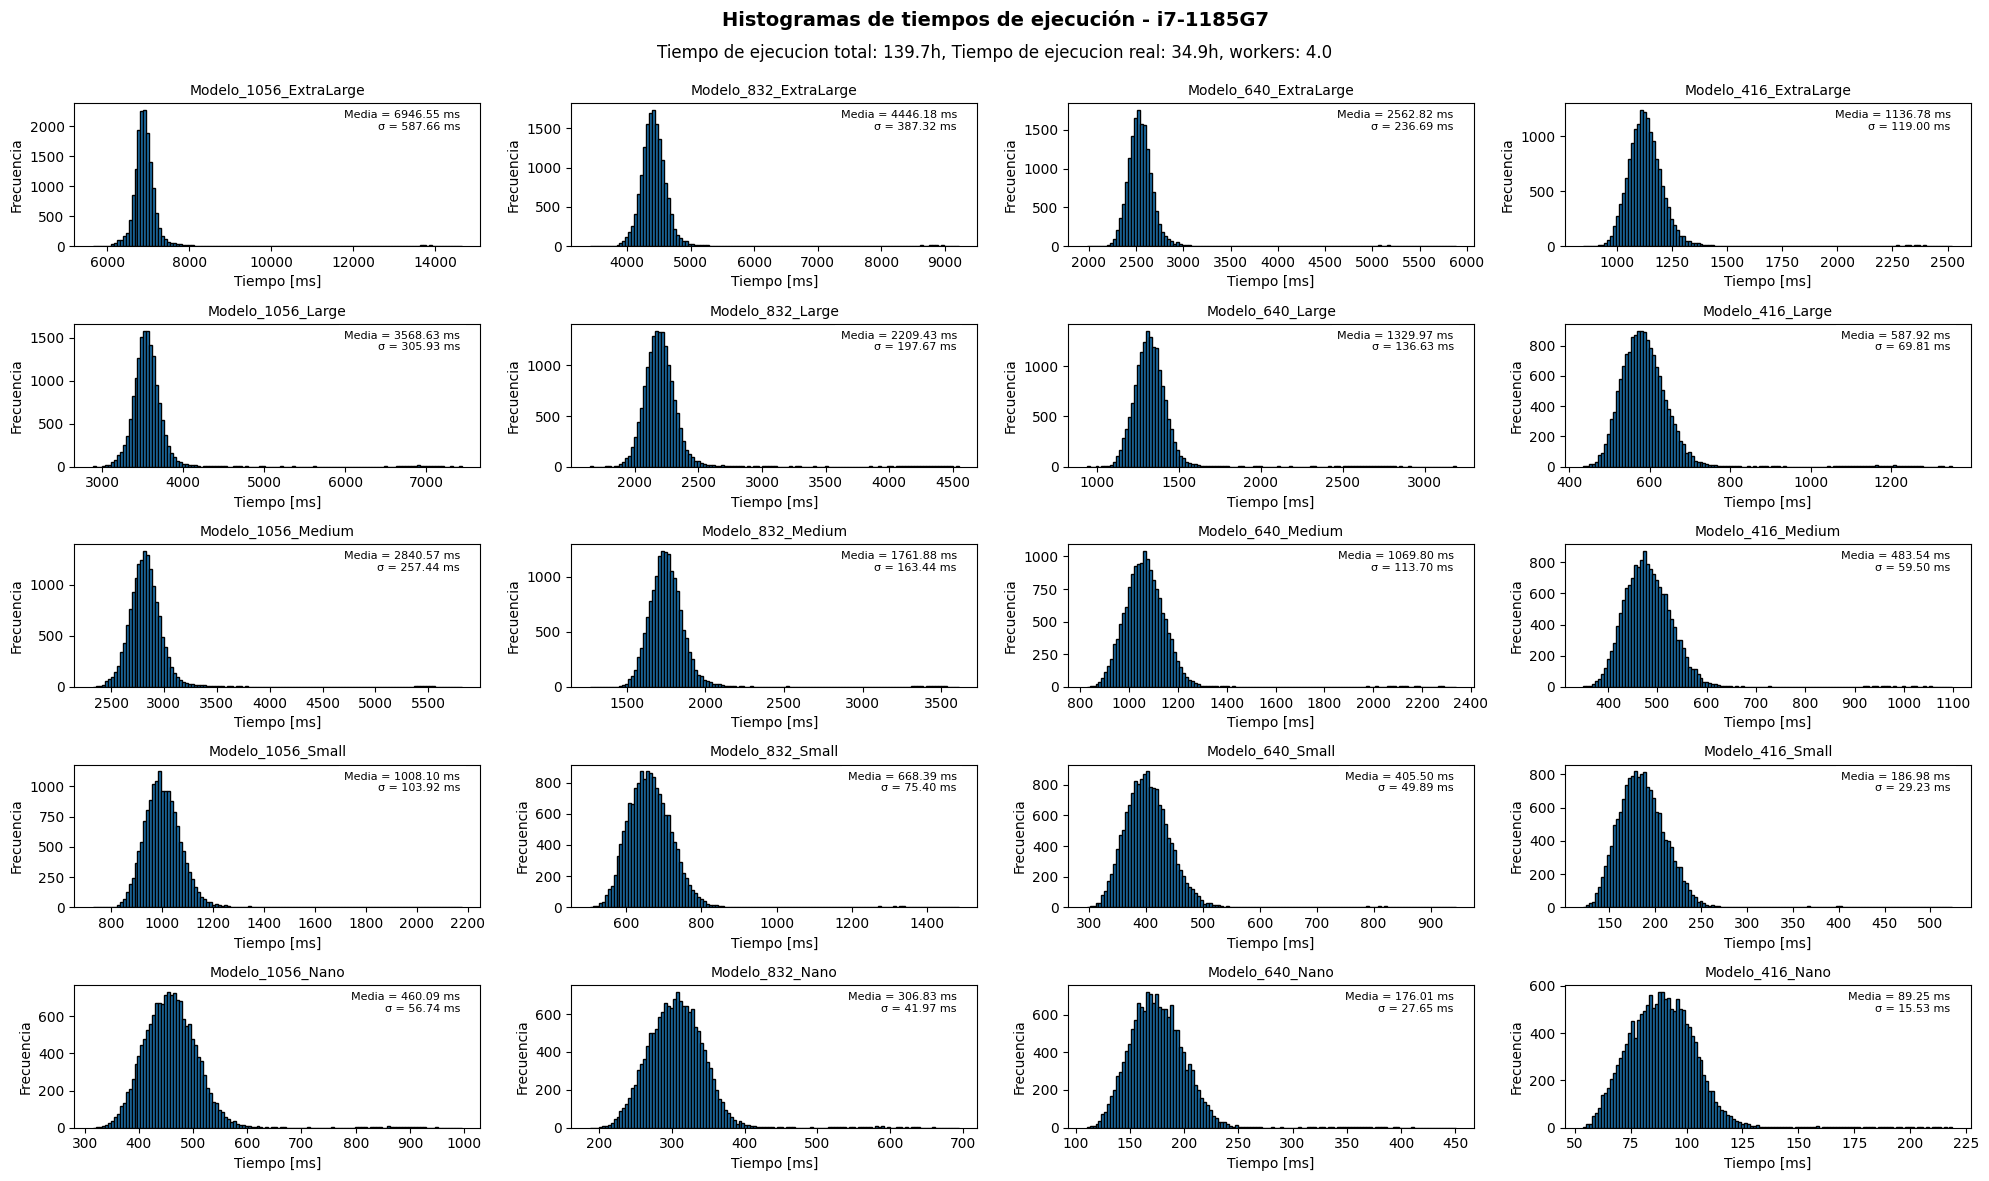

Para el dispositivo i9-11900k, se tienen los siguientes tiempos de ejecucion: 


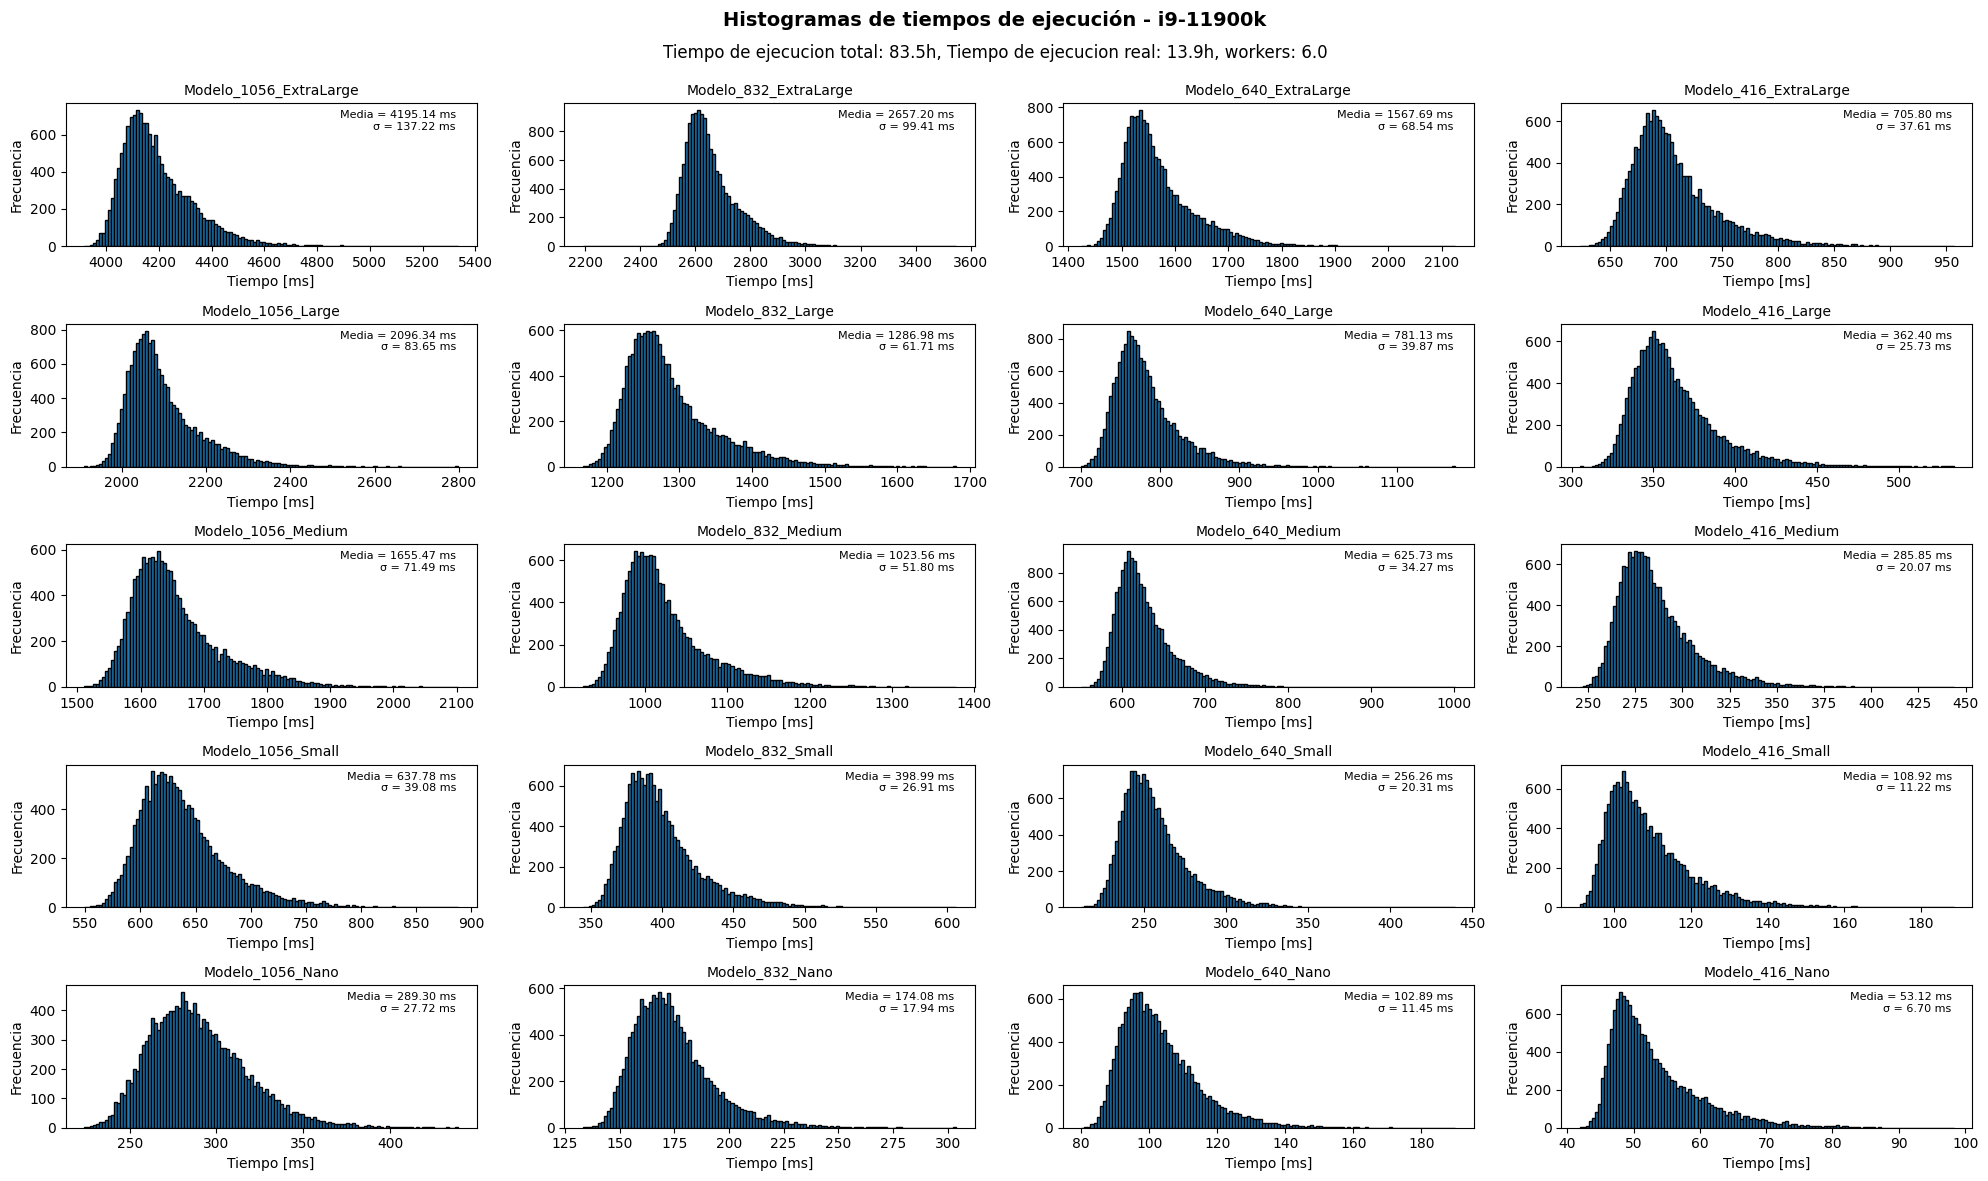

Para el dispositivo RTX4090, se tienen los siguientes tiempos de ejecucion: 


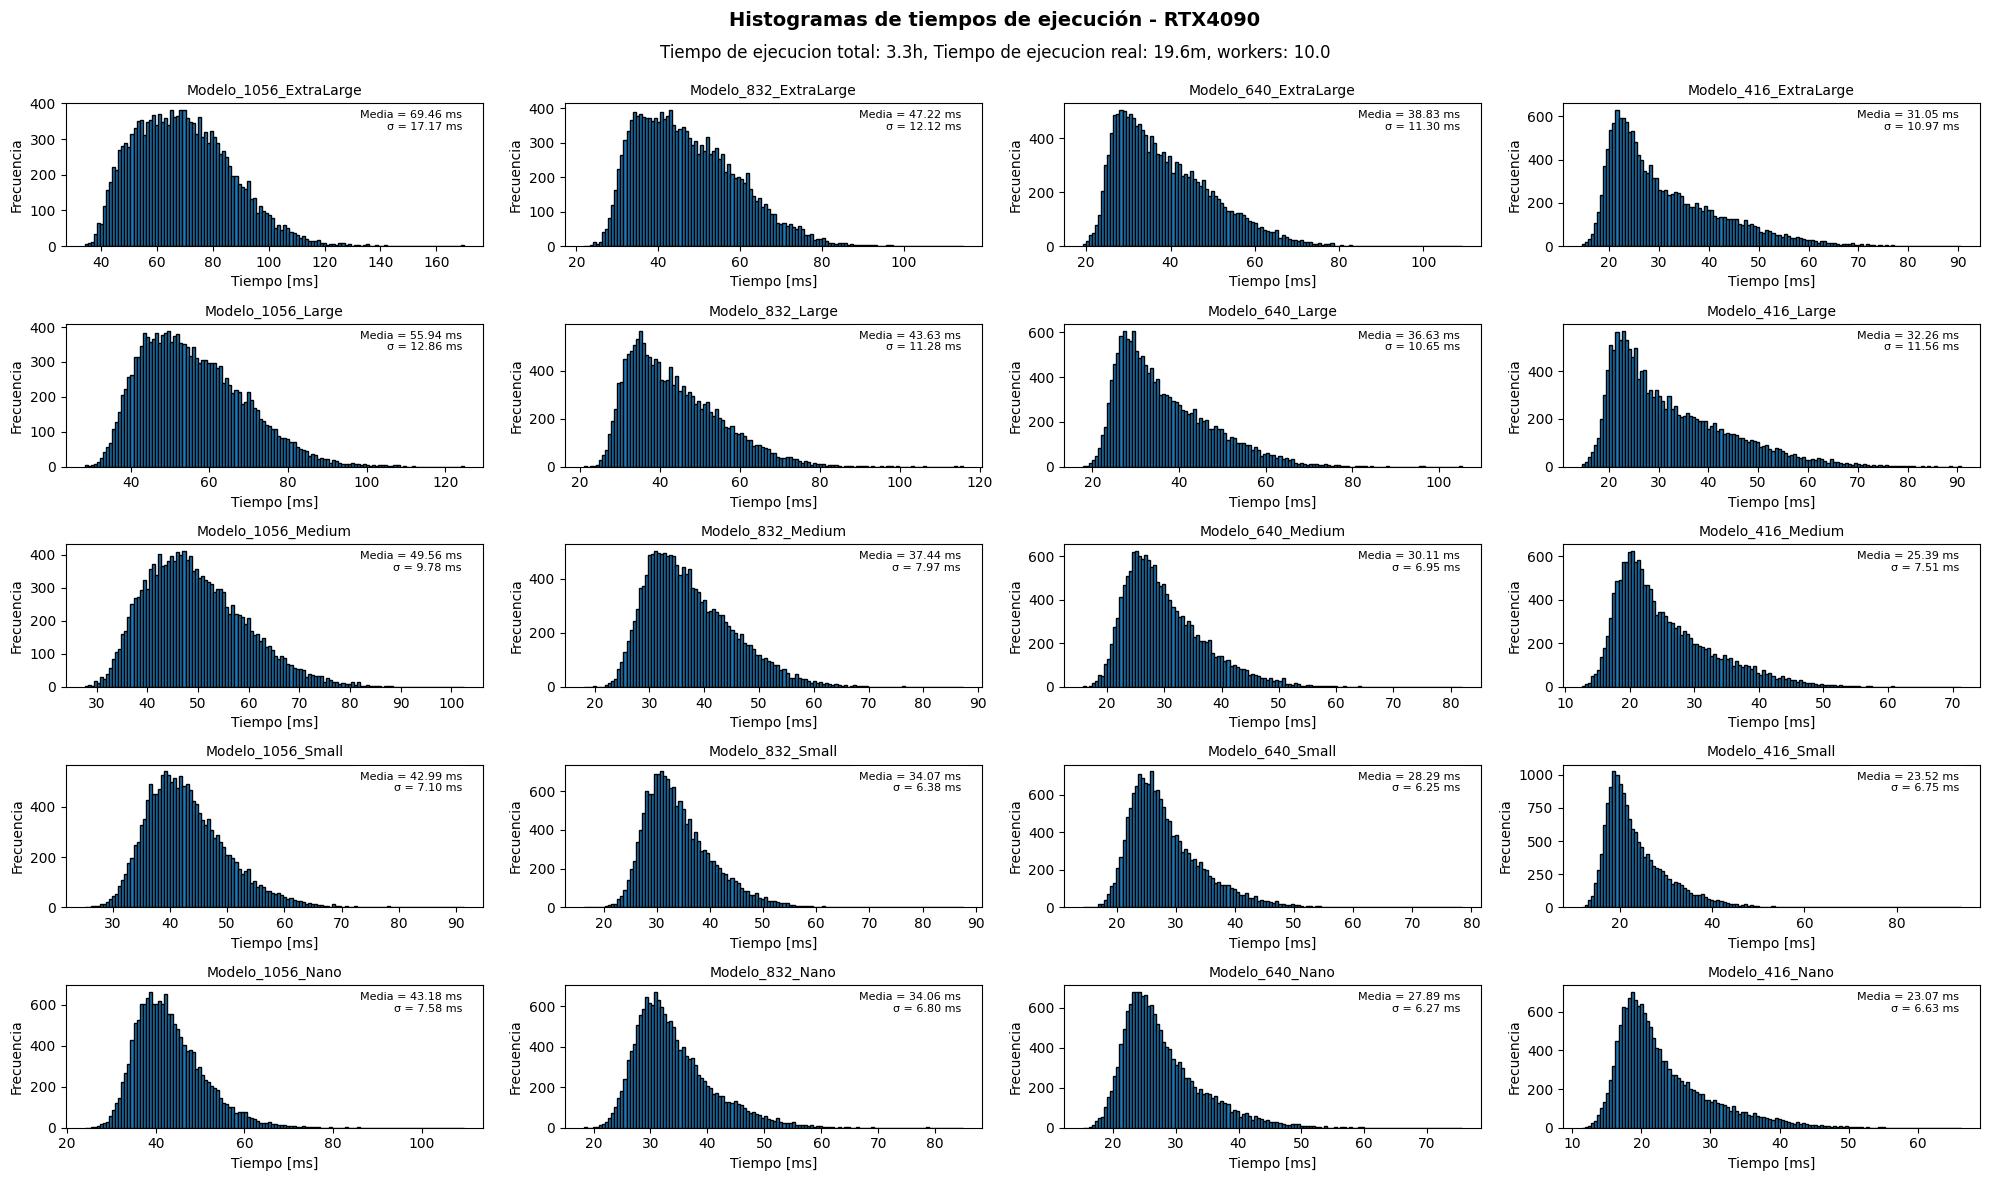

Para el dispositivo RTXA4000, se tienen los siguientes tiempos de ejecucion: 


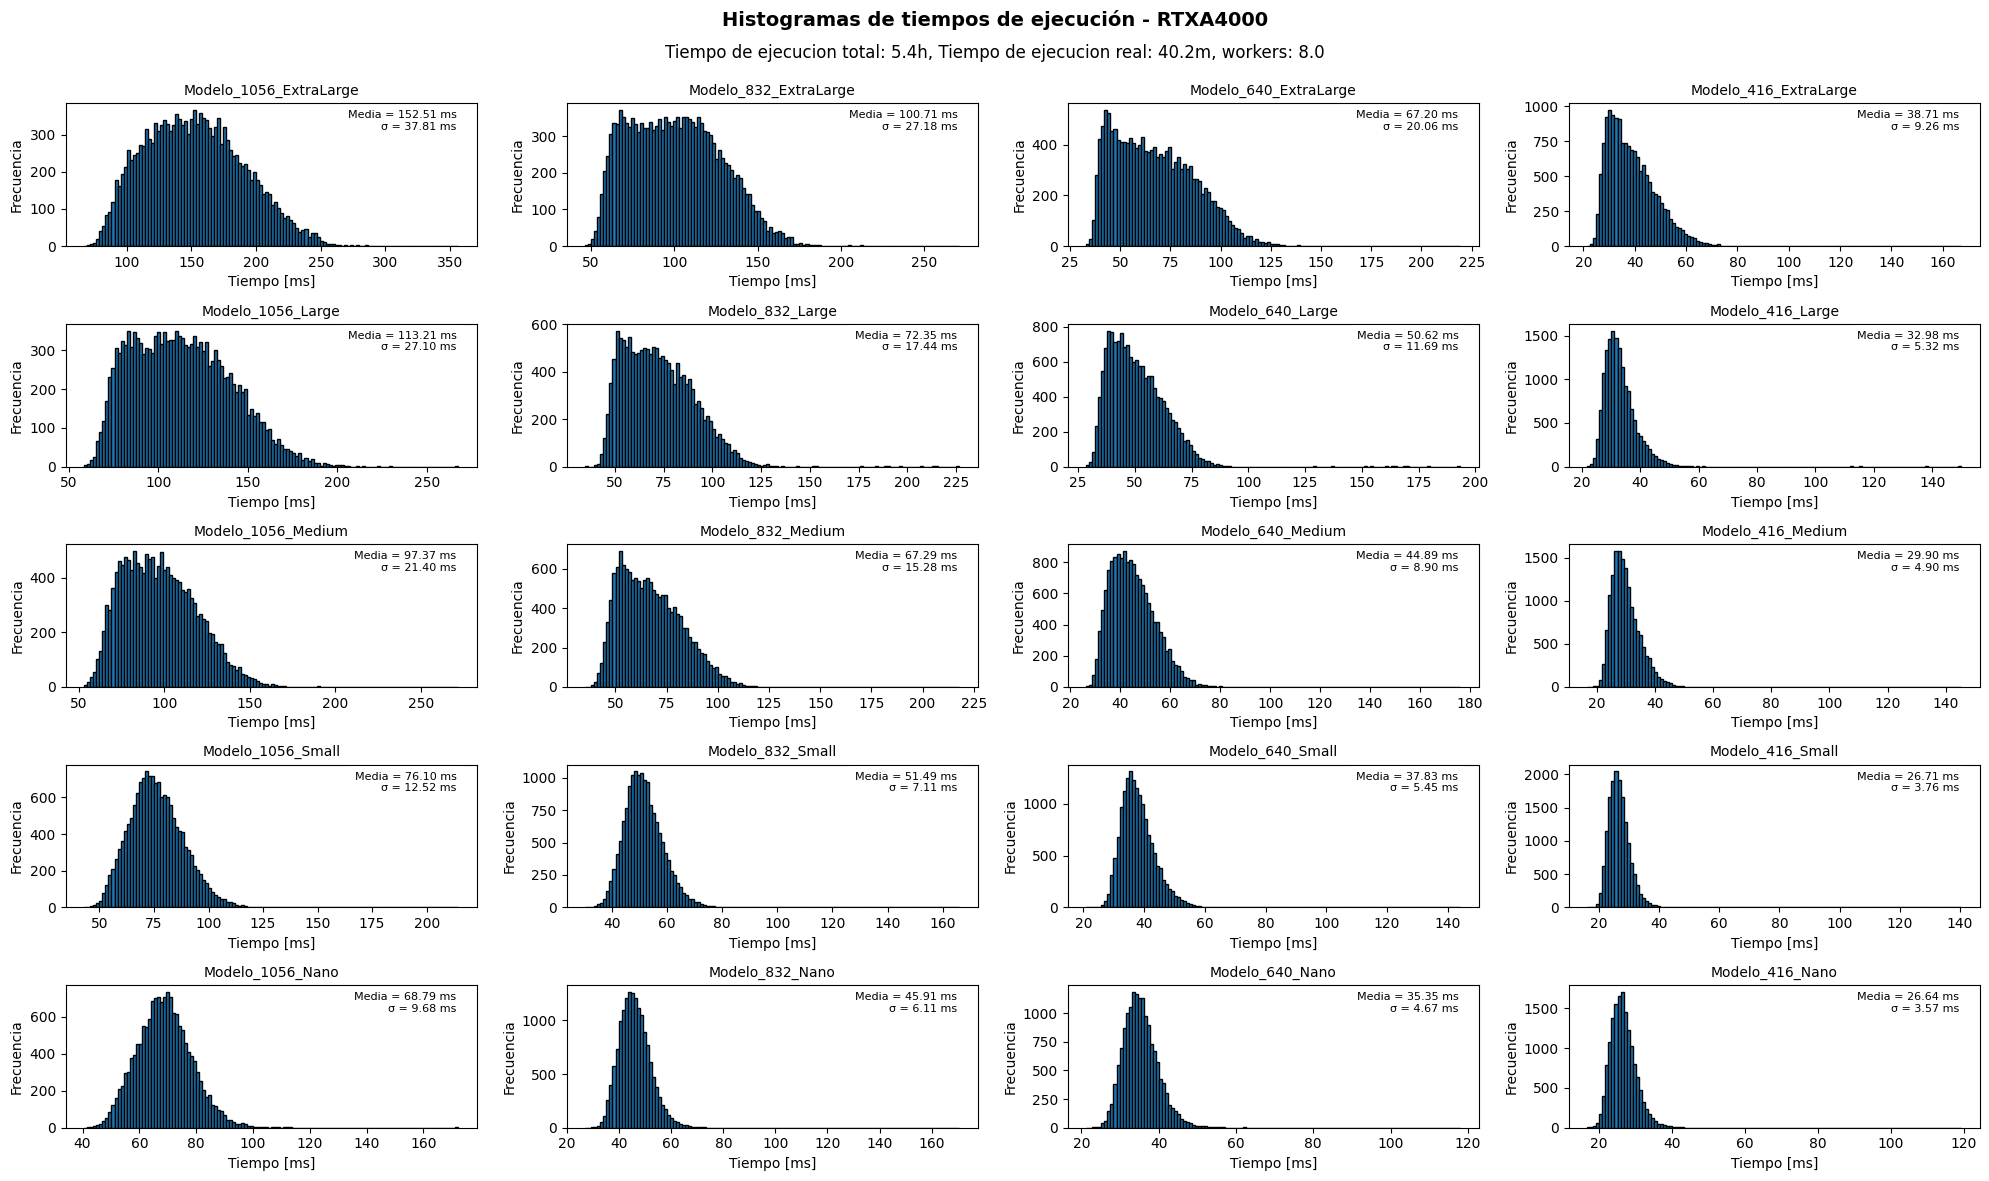

Para el dispositivo Ryzen7-9800X3D, se tienen los siguientes tiempos de ejecucion: 


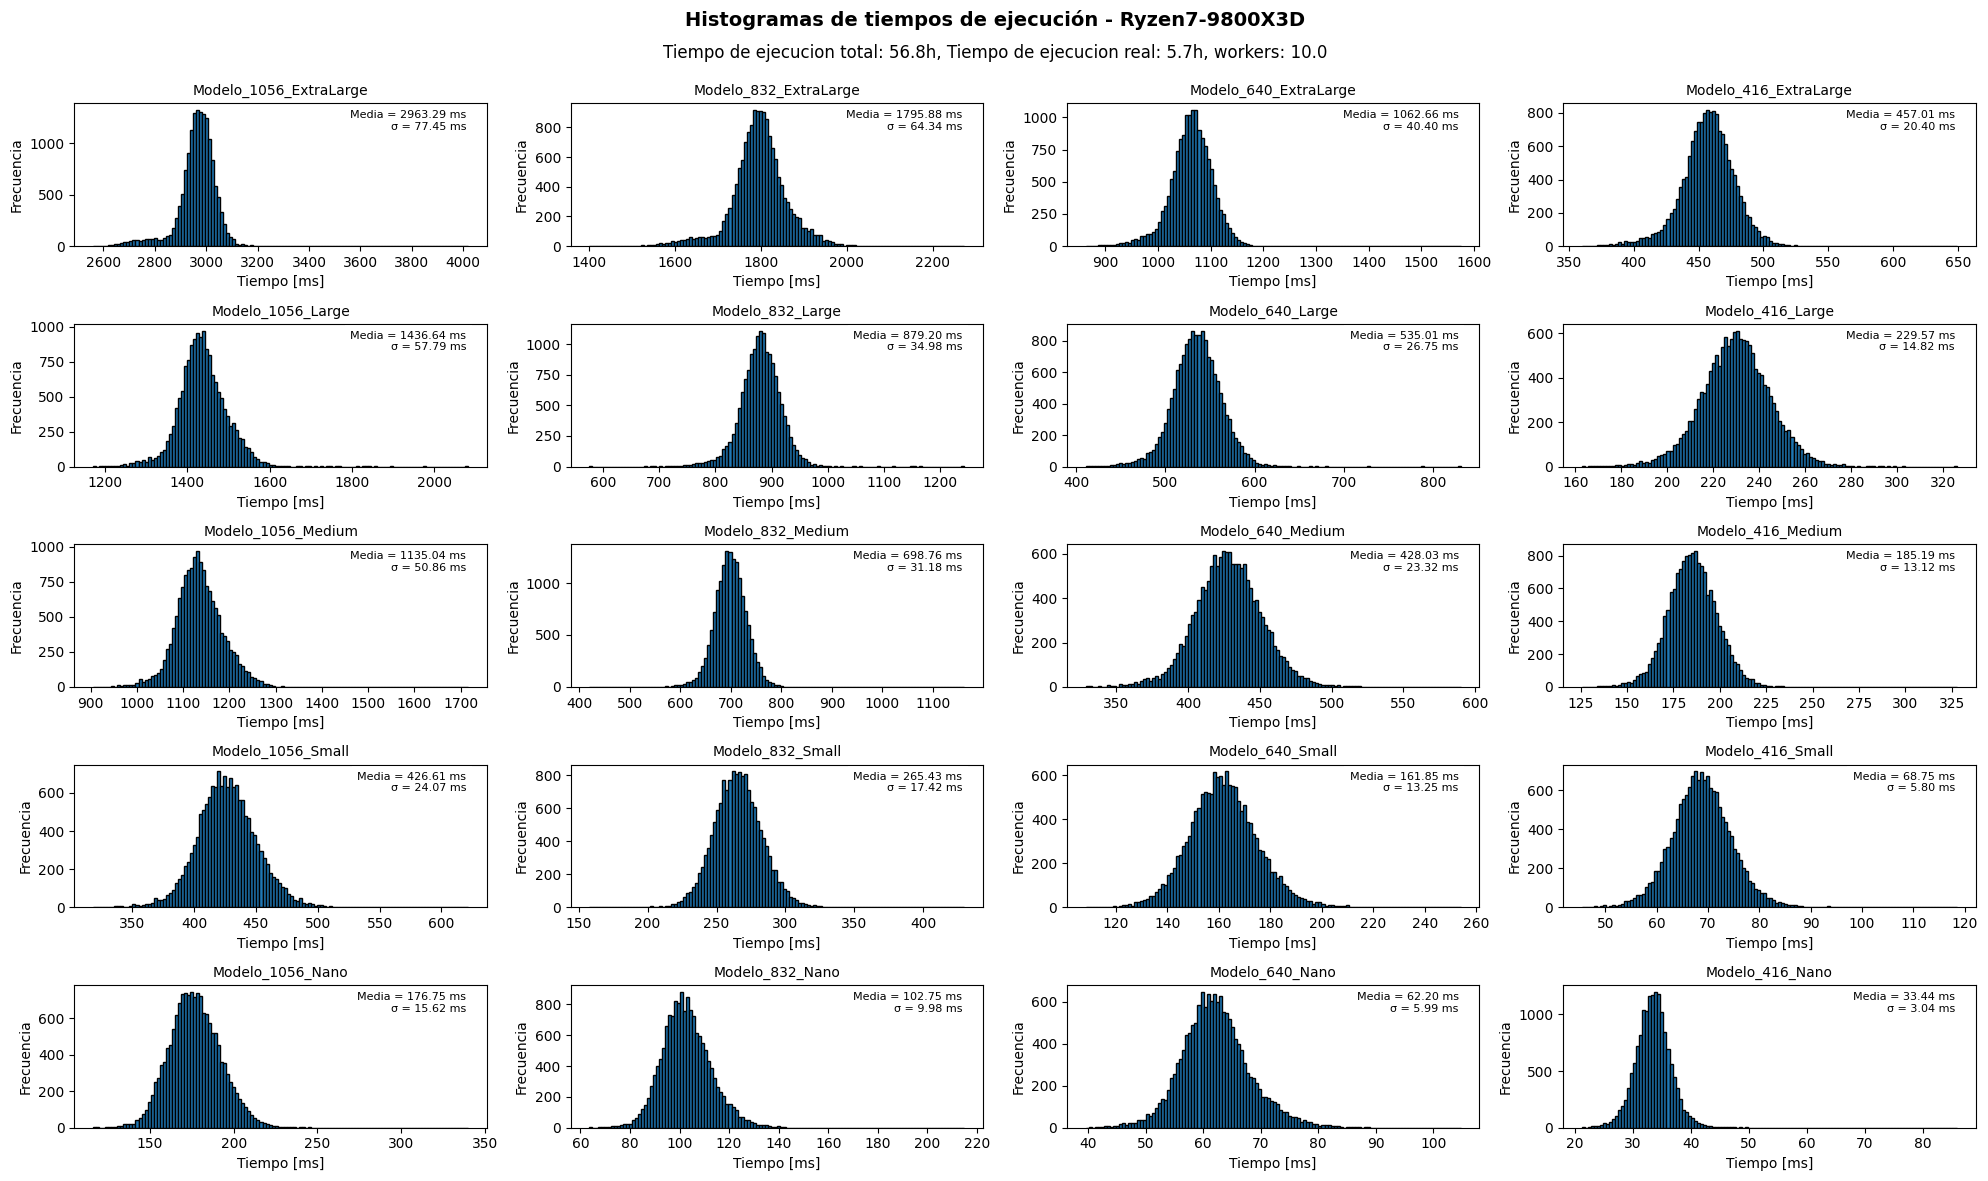

In [148]:
# ---------- Ejecucion -------------
Ruta_Archivos = os.path.normpath(os.path.join("..","..","..","Resultados_Clasificacion"))
Ruta_Archivos = [os.path.normpath(os.path.join(Ruta_Archivos,file))for file in os.listdir(Ruta_Archivos)]

Ruta_Salida = os.path.normpath(os.path.join("..","..",".."))


type_order = ["ExtraLarge", "Large", "Medium", "Small", "Nano"]
size_order = [1056, 832, 640, 416]

Dispositivos = {}
Resultados_Modelos = {}
Dispositivos_ordenados = {}
Cores_Dispositivos = {}

for file in Ruta_Archivos:
    Dispositivos.update(Clasification_Results(file))
    Cores_Dispositivos[file.split("Results_")[-1].split("_")[0]] = {
        'Cores':float(file.split("_workers")[0].split("_")[-1]),
        'Total time [ms]':0}


for dispositivo, modelos in Dispositivos.items():
    modelos_ordenados = dict(
        sorted(modelos.items(), key=lambda x: modelo_sort_key(x[0], type_order, size_order))
    )
    Dispositivos_ordenados[dispositivo] = modelos_ordenados

for modelo, Resultados in next(iter(Dispositivos_ordenados.values())).items():
    Resultados_Modelos[modelo] = {
        'Embarcacion': [],
        'Falso_Negativo':[],
        'Falso_Positivo':[],
        'No_Embarcacion':[],
        'Probs':[],
    }
    Total_Registros = Resultados['Embarcacion']+Resultados['Falso_Negativo']+Resultados['Falso_Positivo']+Resultados['No_Embarcacion']


for _, Modelos in Dispositivos_ordenados.items():
    for modelo, resultados in Modelos.items():
        for resultado, Valor in resultados.items():
            if(resultado == 'Probs'):
                for prob in Valor:
                    Resultados_Modelos[modelo][resultado].append(prob)
            elif(resultado != 'Speed'):
                Resultados_Modelos[modelo][resultado].append(Valor)
            
print("Matriz de confusion media - (promediado con los experimentos en diversos dispositivos)")
for modelo, resultados in Resultados_Modelos.items():
    print(f"Para el modelo {modelo}:")
    print(f"Embarcaciones: {stats.mean(resultados['Embarcacion'])*100/Total_Registros}±{stats.stdev(resultados['Embarcacion'])*100/Total_Registros}%")
    print(f"Sin embarcaciones: {stats.mean(resultados['No_Embarcacion'])*100/Total_Registros}±{stats.stdev(resultados['No_Embarcacion'])*100/Total_Registros}%")
    print(f"Falso Negativo: {stats.mean(resultados['Falso_Negativo'])*100/Total_Registros}±{stats.stdev(resultados['Falso_Negativo'])*100/Total_Registros}%")
    print(f"Falso Positivo: {stats.mean(resultados['Falso_Positivo'])*100/Total_Registros}±{stats.stdev(resultados['Falso_Positivo'])*100/Total_Registros}%\n")

for dispositivo, modelos in Dispositivos.items():
    print(f"Para el dispositivo {dispositivo}, se tienen los siguientes tiempos de ejecucion: ")
    for modelo, resultados in modelos.items():
        print(f"{modelo}: {stats.mean(resultados['Speed']):.2f}±{stats.stdev(resultados['Speed']):.2f} [ms]")
        for speed in resultados['Speed']:
            Cores_Dispositivos[dispositivo]['Total time [ms]']+=speed

    print("\n")

with PdfPages(os.path.normpath(os.path.join(Ruta_Salida,"Ejecucion_Clasificacion_Dispositivo.pdf"))) as pdf:
    for dispositivo, modelos in Dispositivos_ordenados.items():
        print(f"Para el dispositivo {dispositivo}, se tienen los siguientes tiempos de ejecucion: ")
        
        fig, axs = plt.subplots(5, 4, figsize=(20, 12))
        axs = axs.flatten()
        
        for i, (modelo, resultados) in enumerate(modelos.items()):
            if i >= 20:  
                break

            datos = resultados['Speed']
            media = stats.mean(datos)
            sigma = stats.stdev(datos)

            axs[i].hist(datos, bins=int(math.sqrt(len(datos))), edgecolor="black")
            axs[i].set_title(modelo, fontsize=10)

            axs[i].text(
                0.95, 0.95,
                f"Media = {media:.2f} ms\nσ = {sigma:.2f} ms",
                ha="right", va="top",
                transform=axs[i].transAxes,
                fontsize=8,
                bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")  
            )

            axs[i].set_xlabel("Tiempo [ms]")
            axs[i].set_ylabel("Frecuencia")

        for j in range(i + 1, len(axs)):
            axs[j].axis("off")

        Tiempo_Total = Cores_Dispositivos[dispositivo]['Total time [ms]']/(1000*60*60)
        Tiempo_Total = f"{round(Tiempo_Total,1)}h"
        Tiempo_Real = Cores_Dispositivos[dispositivo]['Total time [ms]']/(1000*60*60*Cores_Dispositivos[dispositivo]['Cores'])
        if(Tiempo_Real<1):
            Tiempo_Real = f"{round(Tiempo_Real*60,1)}m"
        else:
            Tiempo_Real = f"{round(Tiempo_Real,1)}h"
        

        plt.suptitle(f"Histogramas de tiempos de ejecución - {dispositivo}", 
                        fontsize=14, fontweight="bold")
        fig.text(0.5, 0.94, f"Tiempo de ejecucion total: {Tiempo_Total}, Tiempo de ejecucion real: {Tiempo_Real}, workers: {Cores_Dispositivos[dispositivo]['Cores']}", ha="center", fontsize=12, fontweight="normal")

        plt.tight_layout(rect=[0, 0, 1, 0.96])

        plt.show()


        pdf.savefig(fig)
        plt.close(fig)  




Matriz de confusion media - (promediado con los experimentos en diversos dispositivos)
Para el modelo Modelo_1056_ExtraLarge:
Embarcaciones: 1.6355276177172458±0.0%
Sin embarcaciones: 79.71596531051743±0.0%
Falso Negativo: 0.10476689366160294±0.0%
Falso Positivo: 19.361503986962344±0.012346896825328225%

Para el modelo Modelo_832_ExtraLarge:
Embarcaciones: 1.8305104475874512±0.004115632275109409%
Sin embarcaciones: 79.66940224666783±0.0%
Falso Negativo: 0.1105872766428031±0.0%
Falso Positivo: 18.826028752691926±0.004115632275109409%

Para el modelo Modelo_640_ExtraLarge:
Embarcaciones: 1.6006053198300447±0.0%
Sin embarcaciones: 79.57627611896862±0.0%
Falso Negativo: 0.1862522553984052±0.0%
Falso Positivo: 19.800942902042955±0.0%

Para el modelo Modelo_416_ExtraLarge:
Embarcaciones: 1.7723066177754496±0.004115632275109409%
Sin embarcaciones: 79.57627611896862±0.0%
Falso Negativo: 0.285198766078808±0.0%
Falso Positivo: 17.184680751993483±0.004115632275109409%

Para el modelo Modelo_1056_

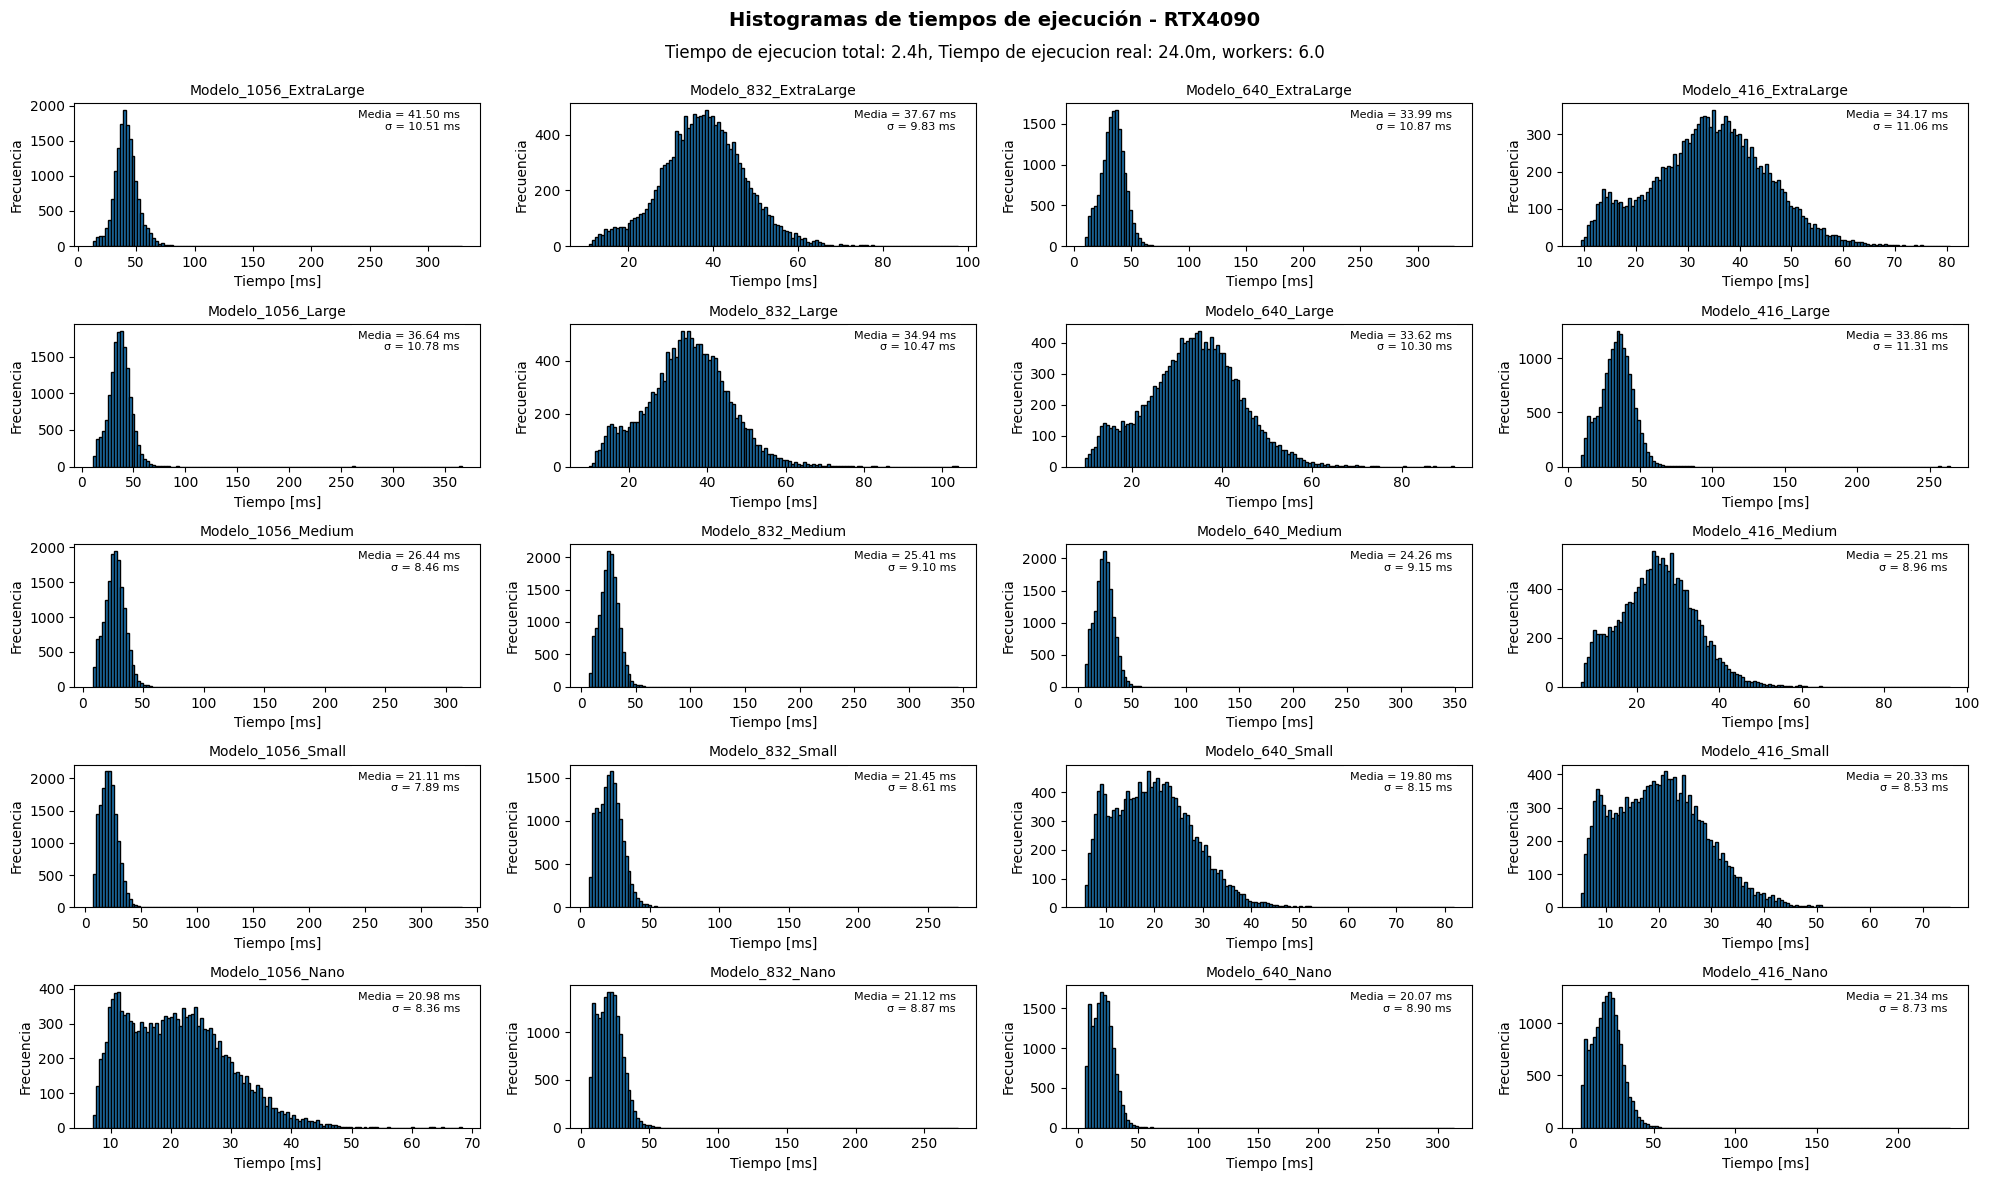

Para el dispositivo Ryzen7-9800X3D, se tienen los siguientes tiempos de ejecucion: 


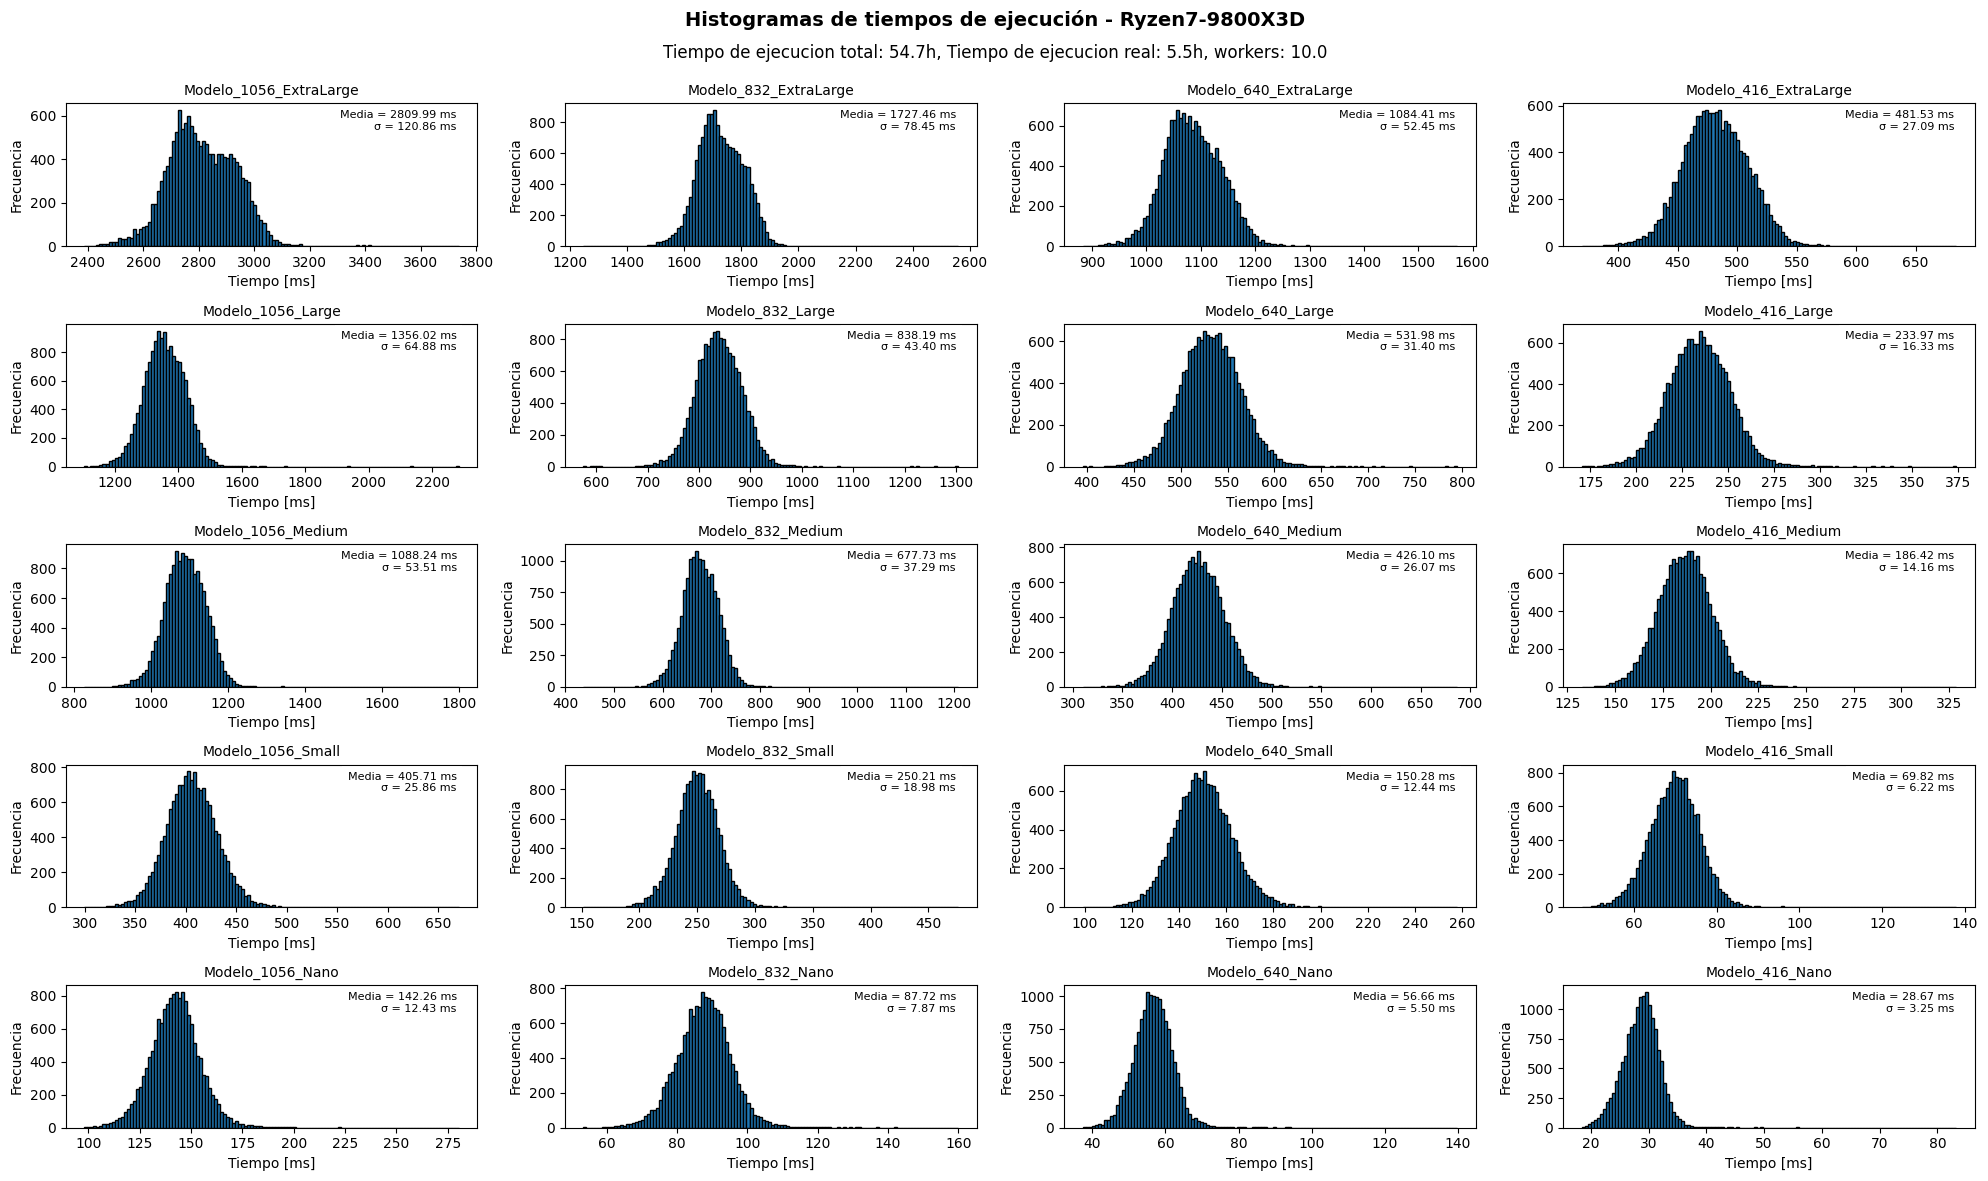

In [149]:
Ruta_Archivos = os.path.normpath(os.path.join("..","..","..","Resultados_Segmentacion"))
Ruta_Archivos = [os.path.normpath(os.path.join(Ruta_Archivos,file))for file in os.listdir(Ruta_Archivos)]

Ruta_Salida = os.path.normpath(os.path.join("..","..",".."))


type_order = ["ExtraLarge", "Large", "Medium", "Small", "Nano"]
size_order = [1056, 832, 640, 416]

Dispositivos = {}
Resultados_Modelos = {}
Dispositivos_ordenados = {}
Cores_Dispositivos = {}

for file in Ruta_Archivos:
    Dispositivos.update(Segmentation_Results(file))
    Cores_Dispositivos[file.split("Results_")[-1].split("_")[0]] = {
        'Cores':float(file.split("_workers")[0].split("_")[-1]),
        'Total time [ms]':0}

for dispositivo, modelos in Dispositivos.items():
    modelos_ordenados = dict(
        sorted(modelos.items(), key=lambda x: modelo_sort_key(x[0], type_order, size_order))
    )
    Dispositivos_ordenados[dispositivo] = modelos_ordenados


for modelo, Resultados in next(iter(Dispositivos_ordenados.values())).items():
    Resultados_Modelos[modelo] = {
        'Embarcacion': [],
        'Falso_Negativo':[],
        'Falso_Positivo':[],
        'No_Embarcacion':[],
        'Probs':[],
    }
    Total_Registros = Resultados['Embarcacion']+Resultados['Falso_Negativo']+Resultados['Falso_Positivo']+Resultados['No_Embarcacion']


for _, Modelos in Dispositivos_ordenados.items():
    for modelo, resultados in Modelos.items():
        for resultado, Valor in resultados.items():
            if(resultado == 'Probs'):
                for prob in Valor:
                    Resultados_Modelos[modelo][resultado].append(prob)
            elif(resultado != 'Speed'):
                Resultados_Modelos[modelo][resultado].append(Valor)
            
print("Matriz de confusion media - (promediado con los experimentos en diversos dispositivos)")
for modelo, resultados in Resultados_Modelos.items():
    print(f"Para el modelo {modelo}:")
    print(f"Embarcaciones: {stats.mean(resultados['Embarcacion'])*100/Total_Registros}±{stats.stdev(resultados['Embarcacion'])*100/Total_Registros}%")
    print(f"Sin embarcaciones: {stats.mean(resultados['No_Embarcacion'])*100/Total_Registros}±{stats.stdev(resultados['No_Embarcacion'])*100/Total_Registros}%")
    print(f"Falso Negativo: {stats.mean(resultados['Falso_Negativo'])*100/Total_Registros}±{stats.stdev(resultados['Falso_Negativo'])*100/Total_Registros}%")
    print(f"Falso Positivo: {stats.mean(resultados['Falso_Positivo'])*100/Total_Registros}±{stats.stdev(resultados['Falso_Positivo'])*100/Total_Registros}%\n")

for dispositivo, modelos in Dispositivos.items():
    print(f"Para el dispositivo {dispositivo}, se tienen los siguientes tiempos de ejecucion: ")
    for modelo, resultados in modelos.items():
        print(f"{modelo}: {stats.mean(resultados['Speed']):.2f}±{stats.stdev(resultados['Speed']):.2f} [ms]")

        for speed in resultados['Speed']:
            Cores_Dispositivos[dispositivo]['Total time [ms]']+=speed
            
    print("\n")

with PdfPages(os.path.normpath(os.path.join(Ruta_Salida,"Ejecucion_Segmentacion_Dispositivo.pdf"))) as pdf:
    for dispositivo, modelos in Dispositivos_ordenados.items():
        print(f"Para el dispositivo {dispositivo}, se tienen los siguientes tiempos de ejecucion: ")
        
        fig, axs = plt.subplots(5, 4, figsize=(20, 12))
        axs = axs.flatten()
        
        for i, (modelo, resultados) in enumerate(modelos.items()):
            if i >= 20:  
                break

            datos = resultados['Speed']
            media = stats.mean(datos)
            sigma = stats.stdev(datos)

            axs[i].hist(datos, bins=int(math.sqrt(len(datos))), edgecolor="black")
            axs[i].set_title(modelo, fontsize=10)

            axs[i].text(
                0.95, 0.95,
                f"Media = {media:.2f} ms\nσ = {sigma:.2f} ms",
                ha="right", va="top",
                transform=axs[i].transAxes,
                fontsize=8,
                bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")  
            )

            axs[i].set_xlabel("Tiempo [ms]")
            axs[i].set_ylabel("Frecuencia")

        for j in range(i + 1, len(axs)):
            axs[j].axis("off")


        Tiempo_Total = Cores_Dispositivos[dispositivo]['Total time [ms]']/(1000*60*60)
        Tiempo_Total = f"{round(Tiempo_Total,1)}h"
        Tiempo_Real = Cores_Dispositivos[dispositivo]['Total time [ms]']/(1000*60*60*Cores_Dispositivos[dispositivo]['Cores'])
        if(Tiempo_Real<1):
            Tiempo_Real = f"{round(Tiempo_Real*60,1)}m"
        else:
            Tiempo_Real = f"{round(Tiempo_Real,1)}h"
        

        plt.suptitle(f"Histogramas de tiempos de ejecución - {dispositivo}", 
                        fontsize=14, fontweight="bold")
        fig.text(0.5, 0.94, f"Tiempo de ejecucion total: {Tiempo_Total}, Tiempo de ejecucion real: {Tiempo_Real}, workers: {Cores_Dispositivos[dispositivo]['Cores']}", ha="center", fontsize=12, fontweight="normal")

        plt.tight_layout(rect=[0, 0, 1, 0.96])

        plt.show()


        pdf.savefig(fig)
        plt.close(fig)  


La base de datos contiene un aproximado de 10966 correos diferentes
La cantidad de correos sin imagenes son: 5076, corresponde a un 46.289% de los correos

La cantidad de correos con imagenes son: 5890, corresponde a un 53.711% de los correos
Los correos que tienen imagenes pero no contienen embarcaciones son: 5280, corresponde a un 48.149% de los correos
Los correos que tienen imagenes y que contienen embarcaciones son: 610, corresponde a un 5.563% de los correos

En total se disponen de 13718 Imagenes sin embarcaciones
En total se disponen de 1877 Imagenes con embarcaciones
Se obtuvieron un total de 15595 Imagenes

Dentro de los correos se identificaron 3732 ID unicos, clasificados por el radar
El promedio de correos repetidos que llegan por ID es de: 5.539
El promedio de imagenes por correo que contiene imagenes es de: 2.648


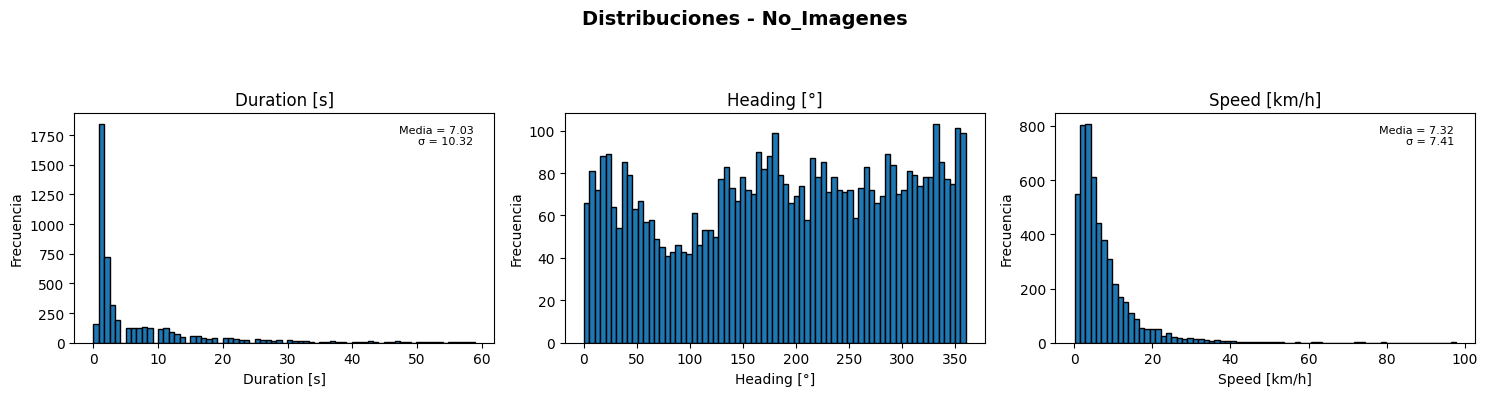

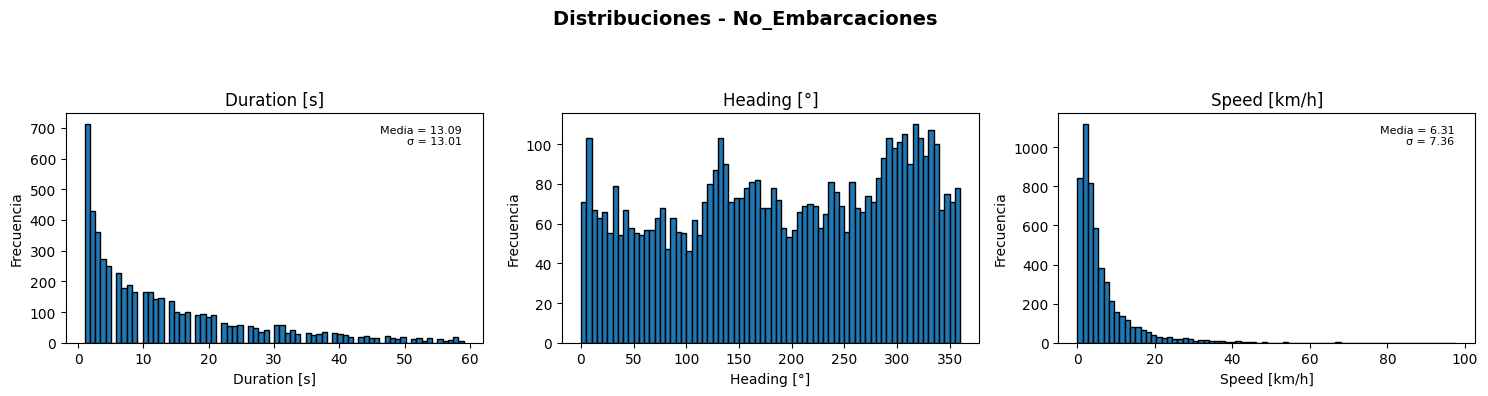

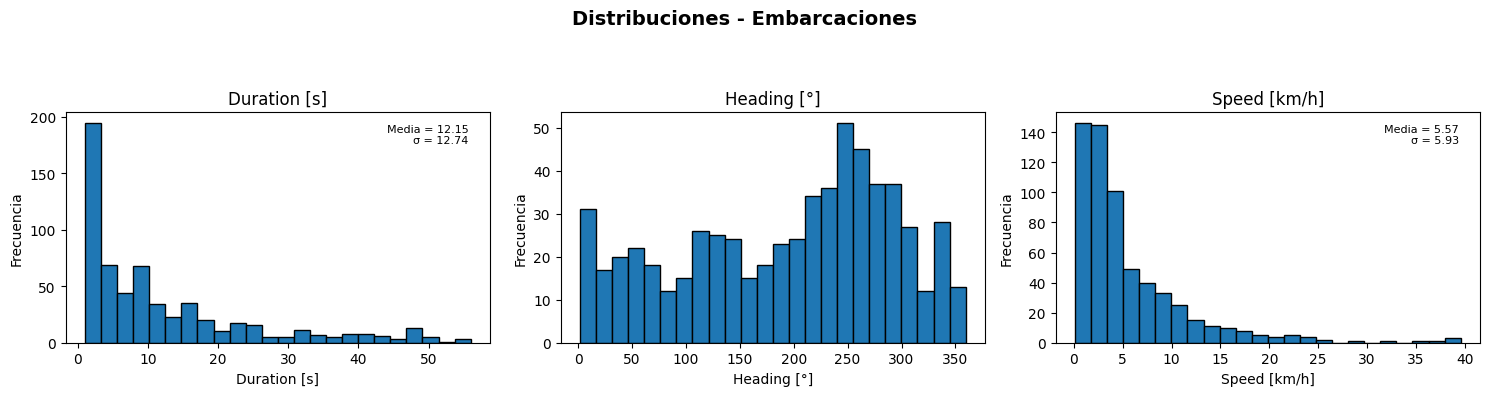

In [98]:
Ruta_DB = os.path.normpath(os.path.join("..","..","..","DB_Embarcaciones.csv"))

Database = {
    "No_Imagenes":{
        'Duration [s]':[],
        'Latitude':[],
        'Longitude':[],
        'Heading [°]':[],
        'Speed [km/h]':[],
        'System_Time':[]
    },
    "No_Embarcaciones":{
        'Duration [s]':[],
        'Latitude':[],
        'Longitude':[],
        'Heading [°]':[],
        'Speed [km/h]':[],
        'System_Time':[]
    },
    "Embarcaciones":{        
        'Duration [s]':[],
        'Latitude':[],
        'Longitude':[],
        'Heading [°]':[],
        'Speed [km/h]':[],
        'System_Time':[]}}

Registros_Repetidos_No_Embarcaciones = 0
Registros_Repetidos_Embarcaciones = 0
track_subs = {}
pair_counts = {}

with open(Ruta_DB, mode="r", newline='', encoding='utf-8') as infile:
    reader = csv.DictReader(infile)
    header = reader.fieldnames

    # Conjunto para evitar duplicados
    registros_vistos = set()
    registros_vistos_Auxiliar = set()
    registros_imagenes_Auxiliar = set()

    for row in reader:
        # clave única: combinación de TrackID y Sub_ID
        clave_unica = (row['Track_ID'], row['Sub_ID'])
        clave_unica_auxiliar = (row['Track_ID'])

        if row['Track_ID'] not in track_subs:
                track_subs[row['Track_ID']] = 0

        track_subs[row['Track_ID']]+=1

        
        if row['Image_Name'] != 'N/A':
        
            # Contar ocurrencias del par
            if clave_unica not in pair_counts:
                pair_counts[clave_unica] = 0
            pair_counts[clave_unica] += 1





        if clave_unica_auxiliar not in registros_vistos_Auxiliar:
            registros_vistos_Auxiliar.add(clave_unica_auxiliar)


        if clave_unica in registros_vistos:
            if(row['Main_Label'] == '0'):
                Registros_Repetidos_No_Embarcaciones+=1
            elif(row['Main_Label'] == '1'):
                Registros_Repetidos_Embarcaciones+=1

            continue  # ya procesado, saltar
        registros_vistos.add(clave_unica)

        # Clasificación según tus condiciones
        if row['Image_Name'] == 'N/A':
            Database["No_Imagenes"]['Duration [s]'].append(extract_number(row['Duration']))
            Database["No_Imagenes"]['Latitude'].append(extract_number(row['Latitude']))
            Database["No_Imagenes"]['Longitude'].append(extract_number(row['Longitude']))
            Database["No_Imagenes"]['Heading [°]'].append(extract_number(row['Heading']))
            Database["No_Imagenes"]['Speed [km/h]'].append(extract_number(row['Speed']))
            Database["No_Imagenes"]['System_Time'].append(datetime.strptime(row['System_Time'], "%Y-%m-%d %H:%M:%S"))


        elif row['Main_Label'] == '0':
            Database["No_Embarcaciones"]['Duration [s]'].append(extract_number(row['Duration']))
            Database["No_Embarcaciones"]['Latitude'].append(extract_number(row['Latitude']))
            Database["No_Embarcaciones"]['Longitude'].append(extract_number(row['Longitude']))
            Database["No_Embarcaciones"]['Heading [°]'].append(extract_number(row['Heading']))
            Database["No_Embarcaciones"]['Speed [km/h]'].append(extract_number(row['Speed']))
            Database["No_Embarcaciones"]['System_Time'].append(datetime.strptime(row['System_Time'], "%Y-%m-%d %H:%M:%S"))

        else:
            Database["Embarcaciones"]['Duration [s]'].append(extract_number(row['Duration']))
            Database["Embarcaciones"]['Latitude'].append(extract_number(row['Latitude']))
            Database["Embarcaciones"]['Longitude'].append(extract_number(row['Longitude']))
            Database["Embarcaciones"]['Heading [°]'].append(extract_number(row['Heading']))
            Database["Embarcaciones"]['Speed [km/h]'].append(extract_number(row['Speed']))
            Database["Embarcaciones"]['System_Time'].append(datetime.strptime(row['System_Time'], "%Y-%m-%d %H:%M:%S"))


for categoria, datos in Database.items():
    if (categoria == 'No_Imagenes'):
        Correos_Sin_Imagenes = len(datos['Duration [s]'])
    elif (categoria == 'No_Embarcaciones'):
        Correos_Sin_Embarcaciones = len(datos['Duration [s]'])
    else:
        Correos_Con_Embarcaciones = len(datos['Duration [s]'])

conteos_subs_per_ID = [subs for subs in track_subs.values()]
promedio_subs_por_track = round(sum(conteos_subs_per_ID) / len(conteos_subs_per_ID),3) if conteos_subs_per_ID else 0

conteos_Img_per_subs = [img for img in pair_counts.values()]
promedio_img_por_subs = round(sum(conteos_Img_per_subs) / len(conteos_Img_per_subs),3) if conteos_Img_per_subs else 0

Total_Correos=Correos_Sin_Imagenes+Correos_Sin_Embarcaciones+Correos_Con_Embarcaciones
Total_Imagenes=Correos_Sin_Embarcaciones+Registros_Repetidos_No_Embarcaciones+Correos_Con_Embarcaciones+Registros_Repetidos_Embarcaciones

print(f"La base de datos contiene un aproximado de {Total_Correos} correos diferentes")
print(f"La cantidad de correos sin imagenes son: {Correos_Sin_Imagenes}, corresponde a un {round(Correos_Sin_Imagenes*100/Total_Correos,3)}% de los correos\n")

print(f"La cantidad de correos con imagenes son: {Correos_Sin_Embarcaciones+Correos_Con_Embarcaciones}, corresponde a un {round((Correos_Sin_Embarcaciones+Correos_Con_Embarcaciones)*100/Total_Correos,3)}% de los correos")
print(f"Los correos que tienen imagenes pero no contienen embarcaciones son: {Correos_Sin_Embarcaciones}, corresponde a un {round(Correos_Sin_Embarcaciones*100/Total_Correos,3)}% de los correos")
print(f"Los correos que tienen imagenes y que contienen embarcaciones son: {Correos_Con_Embarcaciones}, corresponde a un {round(Correos_Con_Embarcaciones*100/Total_Correos,3)}% de los correos\n")

print(f"En total se disponen de {Correos_Sin_Embarcaciones+Registros_Repetidos_No_Embarcaciones} Imagenes sin embarcaciones")
print(f"En total se disponen de {Correos_Con_Embarcaciones+Registros_Repetidos_Embarcaciones} Imagenes con embarcaciones")
print(f"Se obtuvieron un total de {Total_Imagenes} Imagenes\n")

print(f"Dentro de los correos se identificaron {len(registros_vistos_Auxiliar)} ID unicos, clasificados por el radar")
print(f"El promedio de correos repetidos que llegan por ID es de: {promedio_subs_por_track}")
print(f"El promedio de imagenes por correo que contiene imagenes es de: {promedio_img_por_subs}")


with PdfPages(os.path.normpath(os.path.join(Ruta_Salida,"histogramas_DB.pdf"))) as pdf:

    for categoria, variables in Database.items():
        fig, axs = plt.subplots(1, 3, figsize=(15, 4))
        fig.suptitle(f"Distribuciones - {categoria}", fontsize=14, fontweight="bold")

        columnas = ["Duration [s]", "Heading [°]", "Speed [km/h]"]

        for idx, nombre_var in enumerate(columnas):
            ax = axs[idx]
            valores = variables.get(nombre_var, [])

            if len(valores) > 0:
                ax.hist(valores, bins=int(math.sqrt(len(valores))), edgecolor="black")
                ax.set_title(nombre_var)
                ax.set_xlabel(nombre_var)
                ax.set_ylabel("Frecuencia")

                # Calcular media y desviación estándar solo en Duration y Speed
                if nombre_var in ["Duration [s]", "Speed [km/h]"] and len(valores) > 1:
                    media = stats.mean(valores)
                    sigma = stats.stdev(valores)

                    ax.text(
                        0.95, 0.95,
                        f"Media = {media:.2f}\nσ = {sigma:.2f}",
                        ha="right", va="top",
                        transform=ax.transAxes,
                        fontsize=8,
                        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
                    )
            else:
                ax.text(0.5, 0.5, "Sin datos", ha="center", va="center")
                ax.set_title(nombre_var)

        plt.tight_layout(rect=[0, 0, 1, 0.9])
        plt.show()

        pdf.savefig(fig)
        plt.close(fig)  



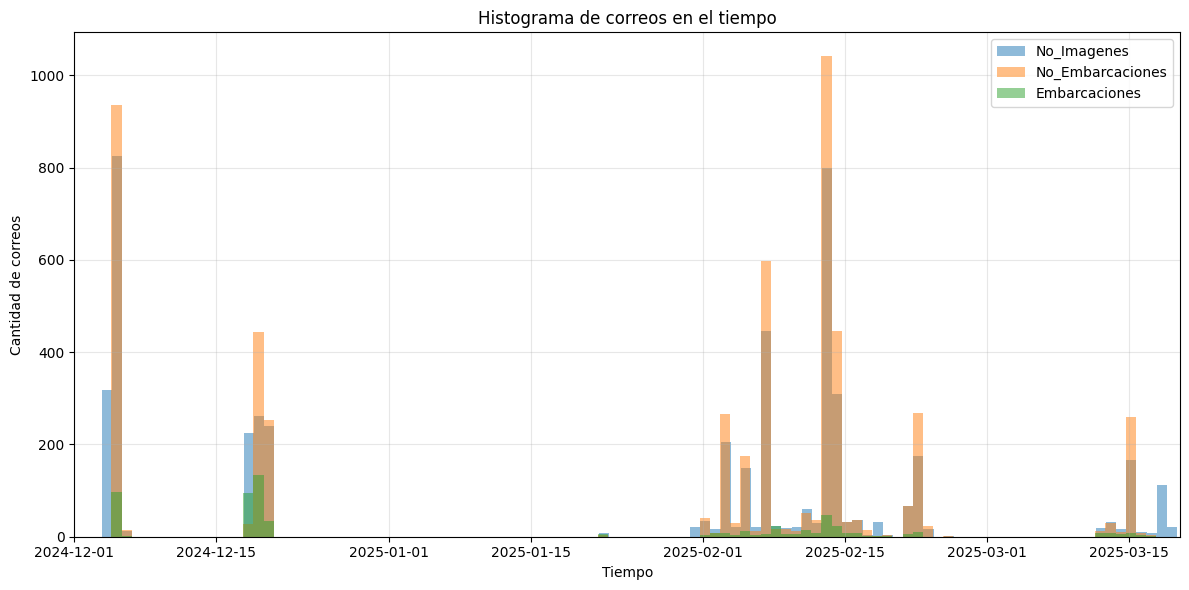

In [4]:
import pandas as pd


plt.figure(figsize=(12,6))

for categoria, datos in Database.items():
    if len(datos["System_Time"]) > 0:
        times = pd.to_datetime(datos["System_Time"])
        min_time = times.min()
        max_time = times.max()
        
        # Definir número de bins = número de días o semanas
        bins = pd.date_range(start=min_time, end=max_time, freq='D')  # un bin por día
        plt.hist(times, bins=bins, alpha=0.5, label=categoria)

fecha_min = pd.to_datetime("2024-12-01 00:00:00")
fecha_max = pd.to_datetime("2025-3-20 00:00:00")
plt.xlim(fecha_min, fecha_max)

plt.title("Histograma de correos en el tiempo")
plt.xlabel("Tiempo")
plt.ylabel("Cantidad de correos")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

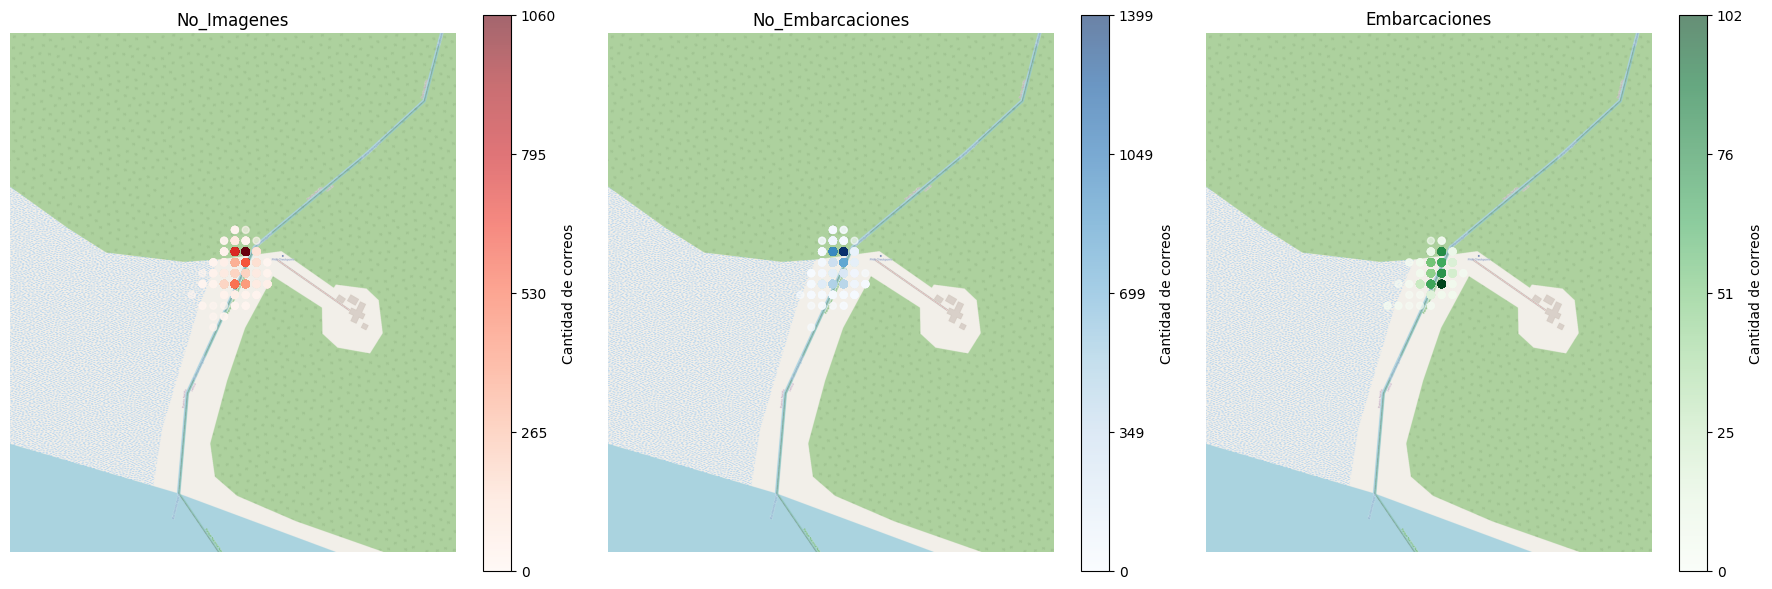

In [89]:
# -----------------------------
# Área de interés
# -----------------------------
center_lat = -3.805534
center_lon = -70.306282
lat_margin = 0.002
lon_margin = 0.002

transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
minx, miny = transformer.transform(center_lon - lon_margin, center_lat - lat_margin)
maxx, maxy = transformer.transform(center_lon + lon_margin, center_lat + lat_margin)

# -----------------------------
# Descargar mapa base
# -----------------------------
img, ext = ctx.bounds2img(minx, miny, maxx, maxy, zoom=19, source=ctx.providers.OpenStreetMap.Mapnik)

# -----------------------------
# Crear GeoDataFrame de puntos
# -----------------------------
points = []
categories = []

for key in Database:
    lats = Database[key]['Latitude']
    lons = Database[key]['Longitude']
    for lat, lon in zip(lats, lons):
        points.append(Point(lon, lat))
        categories.append(key)

gdf = gpd.GeoDataFrame({'category': categories}, geometry=points, crs='EPSG:4326')
gdf_web = gdf.to_crs(epsg=3857)
gdf_web = gdf_web.cx[minx:maxx, miny:maxy]

# -----------------------------
# Colormap por categoría
# -----------------------------
categories_unique = gdf_web['category'].unique()
cmap_dict = {'No_Imagenes':'Reds', 'No_Embarcaciones':'Blues', 'Embarcaciones':'Greens'}

# -----------------------------
# Figura con 3 subplots usando scatter con conteo real
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18,6))

for ax, cat in zip(axes, categories_unique):
    subset = gdf_web[gdf_web['category']==cat]
    if subset.empty:
        continue
    
    x = subset.geometry.x.values
    y = subset.geometry.y.values
    
    # -----------------------------
    # Contar cantidad de puntos en un grid
    # -----------------------------
    gridsize = 50  # Ajusta resolución
    H, xedges, yedges = np.histogram2d(x, y, bins=gridsize, range=[[minx,maxx],[miny,maxy]])
    
    # Asignar a cada punto el conteo de la celda donde cae
    x_idx = np.searchsorted(xedges, x) - 1
    y_idx = np.searchsorted(yedges, y) - 1
    z = H[x_idx, y_idx]
    
    # -----------------------------
    # Plot
    # -----------------------------
    ax.imshow(img, extent=ext, zorder=0)
    
    vmax = np.max(z)  # valor máximo para la colorbar
    sc = ax.scatter(x, y, c=z, s=25, cmap=cmap_dict.get(cat,'hot'), alpha=0.6,
                    vmin=0, vmax=vmax)
    
    cbar = plt.colorbar(sc, ax=ax, label='Cantidad de correos')  
    cbar.set_ticks(np.linspace(0, vmax, num=5))
    cbar.ax.set_yticklabels([f"{int(t)}" for t in np.linspace(0, vmax, num=5)])
    
    ax.set_axis_off()
    ax.set_title(cat)

plt.tight_layout()
#plt.savefig("mapa_calor_scatter_cantidad_3categorias_max.png", dpi=300)
plt.show()